In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd

X_train = pd.read_csv("/content/drive/MyDrive/ethz-aml-project-2/train.csv").iloc[:, 2:].to_numpy()
y_train = pd.read_csv("/content/drive/MyDrive/ethz-aml-project-2/train.csv").iloc[:, 1].to_numpy()
X_test = pd.read_csv("/content/drive/MyDrive/ethz-aml-project-2/test.csv").iloc[:, 1:].to_numpy()

print(X_train.shape, y_train.shape, X_test.shape)

(5117, 17807) (5117,) (3411, 17807)


In [ ]:
pip install biosppy

In [ ]:
pip install neurokit2

In [ ]:
from biosppy.signals import ecg
import neurokit2 as nk

def extract_single_info(x):
  # remove the nan values appended in the end of each sequence
  x = x[~np.isnan(x)]
  _, filtered, rpeaks, _, templates, heart_rate_ts, _ = ecg.ecg(x, 300, show=False)
  _, signals = nk.ecg_delineate(filtered, rpeaks, 300)
  return filtered, rpeaks, templates, heart_rate_ts, signals


In [ ]:
from tqdm import tqdm

# extract information for each sample;
# include the inversion: electrode misplacement could cause the ECG appear flipped,
# but the underlying heart activity does not change; increases signal robustness and prevents bias
# (otherwise might incorrectly classify inverted signals as a separate category)
def extract_info(X, inverse=False):
  Xn = []
  for x in tqdm(X, total=len(X)):
    Xn.append(extract_single_info(x))

  if inverse:
    # update the same bar for the inverse case
    for x in tqdm(X, total=len(X)):
      Xn.append(extract_single_info(-x))

  return Xn

In [ ]:
# the dimension for each info (e.g. cleaned signal, autocorrelation, mean/variance of the epochs) are too large to add into
# the features, try to use bins to compress information, the dimension of the compressed info is nbins.
# Divide xbeg to xend into nbins, the y values whose x values inside the same bin are averaged or only the max
# value is considered based on func.
def reduce_feature_dimension(x, y, xbeg, xend, nbins, func):
    # create equally spaced bin edges
    bin_edges = np.linspace(xbeg, xend, nbins + 1)
    # assign each x value to a bin
    bin_indices = np.searchsorted(bin_edges, x, side='right') - 1
    # calculate bin centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # apply the function to y values in each bin
    binned_values = np.array([func(y[bin_indices == b]) for b in range(nbins)])
    return binned_values

In [ ]:
# mean: central tendency of the data
# median: middle value of the data, robust to outliers
# std: spread of the data around the mean
# var: squared of std, emphasizes larger deviations
def compute_stats(x):
  x = x[~np.isnan(x)]
  if(len(x) == 0):
    return [0, 0, 0, 0]
  if(len(x) == 1):
    return [x[0], x[0], 0, 0]
  else:
    return [np.mean(x), np.median(x), np.std(x), np.var(x)]

In [ ]:
def create_single_feature(x):
  feature = []
  filtered, rpeaks, templates, heart_rate_ts, signals = x

  clip = filtered[rpeaks[0] : rpeaks[-1]]

  # specturm feature
  freq = np.fft.rfftfreq(len(clip), 1/300)
  spec = np.abs(np.fft.rfft(clip)) / len(clip) # normalize, such that the results are independent of the length of data
  spec_rd = reduce_feature_dimension(freq, spec, 0.0, 50.0, 100, np.max) # here xend is chosen based on the result of plot, the freq are bounded by 50.0
  feature += list(spec_rd)

  # autocorrelation feature
  autocorr = np.correlate(clip, clip, mode="full")/len(clip) # normalize for length independency again
  autocorr = autocorr[len(autocorr)//2:]/autocorr.max() # autocorr is symmetric, so just keep the positive half; division by autocorr.max() for data normalization
  time_axis_autocorr = np.linspace(0, len(clip)/300, len(clip))
  autocorr_rd = reduce_feature_dimension(time_axis_autocorr, autocorr, 0.0, 1.3, 100, np.mean)
  feature += list(autocorr_rd)

  # template mean and standard deviation feature
  time_heartbeat = np.linspace(0, templates.shape[1]/300, templates.shape[1])
  avg_signal = np.nanmean(templates, axis=0)
  std_dev = np.nanstd(templates, axis=0)
  avg_signal_rd = reduce_feature_dimension(time_heartbeat, avg_signal, 0.0, time_heartbeat[-1], 100, np.mean)
  std_dev_rd = reduce_feature_dimension(time_heartbeat, std_dev, 0.0, time_heartbeat[-1], 100, np.mean)
  feature += list(avg_signal_rd)
  feature += list(std_dev_rd)

  P_ind = np.array(signals["ECG_P_Peaks"])
  Q_ind = np.array(signals["ECG_Q_Peaks"])
  S_ind = np.array(signals["ECG_S_Peaks"])
  T_ind = np.array(signals["ECG_T_Peaks"])
  # peaks periodicity features
  diff_P = np.diff(P_ind)
  diff_P_feature = compute_stats(diff_P)
  diff_Q = np.diff(Q_ind)
  diff_Q_feature = compute_stats(diff_Q)
  diff_R = np.diff(rpeaks)
  diff_R_feature = compute_stats(diff_R)
  diff_S = np.diff(S_ind)
  diff_S_feature = compute_stats(diff_S)
  diff_T = np.diff(T_ind)
  diff_T_feature = compute_stats(diff_T)
  feature += diff_P_feature
  feature += diff_Q_feature
  feature += diff_R_feature
  feature += diff_S_feature
  feature += diff_T_feature
  # peak amplitude features
  feature += compute_stats(filtered[P_ind[~np.isnan(P_ind)].astype(int)])
  feature += compute_stats(filtered[Q_ind[~np.isnan(Q_ind)].astype(int)])
  feature += compute_stats(filtered[rpeaks[~np.isnan(rpeaks)].astype(int)])
  feature += compute_stats(filtered[S_ind[~np.isnan(S_ind)].astype(int)])
  feature += compute_stats(filtered[T_ind[~np.isnan(T_ind)].astype(int)])
  # PR Interval, PR segment, QRS complex, ST segment, QT interval features
  R_onsets = np.array(signals["ECG_R_Onsets"])
  R_offsets = np.array(signals["ECG_R_Offsets"])
  P_onsets = np.array(signals["ECG_P_Onsets"])
  P_offsets = np.array(signals["ECG_P_Offsets"])
  T_onsets = np.array(signals["ECG_T_Onsets"])
  T_offsets = np.array(signals["ECG_T_Offsets"])
  PR_I = R_onsets - P_onsets
  PR_S = R_onsets - P_offsets
  QRS = R_offsets - R_onsets
  ST_S = T_onsets - R_offsets
  QT_I = T_offsets - R_onsets
  feature += compute_stats(PR_I)
  feature += compute_stats(PR_S)
  feature += compute_stats(QRS)
  feature += compute_stats(ST_S)
  feature += compute_stats(QT_I)

  # heartrate feature
  feature += compute_stats(heart_rate_ts)

  # add hrvanalysis features
  #feature += extract_hrv_features(rpeaks)

  return feature


In [ ]:
def create_features(X):
  Xn = []
  for x in tqdm(X, total=len(X)):
    Xn.append(create_single_feature(x))
  return np.array(Xn)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def visualize_ecg_data(data, labels, examples_per_class):
    # reset matplotlib to default settings
    plt.rcParams.update(plt.rcParamsDefault)

    for class_label in np.unique(labels):
        filtered_data = [(index, record) for index, record in enumerate(data) if labels[index] == class_label]
        filtered_data = filtered_data[:examples_per_class]  # limit to the requested number of examples

        for count, (index, record) in enumerate(filtered_data):
            filtered, rpeaks, templates, _, _ = record

            fig, axes = plt.subplots(2, 2, figsize=(10, 10))
            axes = axes.flatten()

            # plot the filtered signal
            segments = filtered[rpeaks[0]:rpeaks[5]]
            time_axis = np.linspace(0, len(segments)/300, len(segments))
            axes[0].plot(time_axis, segments)
            axes[0].set_xlabel("Time (s)")
            axes[0].set_ylabel("Amplitude")
            axes[0].set_xlim(time_axis[0], time_axis[-1])

            # plot the frequency spectrum, we could see that almost all useful information
            # is within frequency 50
            segments = filtered[rpeaks[0]:rpeaks[-1]]
            freq_axis = np.fft.rfftfreq(len(segments), 1/300)
            spectrum = np.abs(np.fft.rfft(segments))/len(segments) # normalize, such that the results are independent of the length of data
            axes[1].plot(freq_axis, spectrum)
            axes[1].set_xlabel("Frequency (Hz)")
            axes[1].set_ylabel("Magnitude")
            axes[1].set_xlim(0, 50)

            # plot autocorrelation
            autocorr = np.correlate(segments, segments, mode="full")/len(segments) # normalize for length independency again
            autocorr = autocorr[len(autocorr)//2:]/autocorr.max() # autocorr is symmetric, so just keep the positive half; division by autocorr.max() for data normalization
            time_axis_autocorr = np.linspace(0, len(segments)/300, len(segments))
            axes[2].plot(time_axis_autocorr, autocorr)
            axes[2].set_xlabel("Time Lag (s)")
            axes[2].set_ylabel("Autocorrelation")
            axes[2].set_xlim(0, 2.0)

            # plot averaged heartbeat signal
            time_heartbeat = np.linspace(0, templates.shape[1]/300, templates.shape[1])
            avg_signal = np.nanmean(templates, axis=0)
            std_dev = np.nanstd(templates, axis=0)
            axes[3].plot(time_heartbeat, avg_signal)
            axes[3].fill_between(time_heartbeat, avg_signal-std_dev, avg_signal+std_dev, alpha=0.3)
            axes[3].set_xlabel("Time (s)")
            axes[3].set_ylabel("Heartbeat Signal")
            axes[3].set_xlim(0, 0.6)

            # title for the first subplot
            axes[0].set_title(f"Index {index}, Class {class_label}")

            # display the plot
            plt.tight_layout()
            plt.show()


In [ ]:
pip install hrv-analysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 12.9 MB/s eta 0:00:00


In [ ]:
import hrvanalysis

def extract_hrv_features(r_peaks):
    # Preprocessing to produce nn-intervals for the hrvanalysis methods
    # https://pypi.org/project/hrv-analysis/
    rr_intervals_list = np.diff(r_peaks).astype(int)
    # Removes extreme RR intervals that are outside a physiologically reasonable range
    #rr_intervals_without_outliers = hrvanalysis.remove_outliers(rr_intervals=rr_intervals_list, low_rri=300, high_rri=2000)
    # This replace outliers nan values with linear interpolation
    #interpolated_rr_intervals = hrvanalysis.interpolate_nan_values(rr_intervals=rr_intervals_without_outliers, interpolation_method="linear")
    #This remove ectopic beats from signal
    nn_intervals_list = hrvanalysis.remove_ectopic_beats(rr_intervals=rr_intervals_list, method="malik")
    # This replace ectopic beats nan values with linear interpolation
    interpolated_nn_intervals = hrvanalysis.interpolate_nan_values(rr_intervals=nn_intervals_list)

    feature_categories = {
        "time_domain": [
            "mean_nni", "sdnn", "sdsd", "nni_50", "pnni_50", "nni_20",
            "pnni_20", "rmssd", "median_nni", "range_nni", "cvsd", "cvnni",
            "mean_hr", "max_hr", "min_hr", "std_hr"
        ],
        "geometrical": ["triangular_index"],
        "frequency_domain": ["lf", "hf", "lf_hf_ratio", "lfnu", "hfnu", "total_power", "vlf"],
        "csi_cvi": ["csi", "cvi", "Modified_csi"],
        "poincare": ["sd1", "sd2", "ratio_sd2_sd1"],
        "sample_entropy": ["sampen"]
    }

    features = []

    try:
        tdf = hrvanalysis.get_time_domain_features(r_peaks)
        gf = hrvanalysis.get_geometrical_features(r_peaks)
        fdf = hrvanalysis.get_frequency_domain_features(r_peaks)
        cscv = hrvanalysis.get_csi_cvi_features(r_peaks)
        pcp = hrvanalysis.get_poincare_plot_features(r_peaks)
        samp = hrvanalysis.get_sampen(r_peaks)
    except Exception as e:
        print(f"Error calculating HRV features: {e}")
        return []  # Return empty list if any calculation fails

    feature_mapping = {
        "time_domain": tdf,
        "geometrical": gf,
        "frequency_domain": fdf,
        "csi_cvi": cscv,
        "poincare": pcp,
        "sample_entropy": samp
    }

    for category, names in feature_categories.items():
        category_features = feature_mapping.get(category, {})
        for name in names:
            features.append(category_features.get(name, np.nan))  # Use nan if feature is missing

    return features


In [ ]:
X_train_info = extract_info(X_train, inverse=True)

In [ ]:
X_train_feature = create_features(X_train_info)
print(X_train_feature.shape)
print(X_train_feature)

  0%|          | 3/10234 [00:00<12:22, 13.78it/s]

1 ectopic beat(s) have been deleted with malik rule.
2 ectopic beat(s) have been deleted with malik rule.
0 ectopic beat(s) have been deleted with malik rule.
11 ectopic beat(s) have been deleted with malik rule.
2 ectopic beat(s) have been deleted with malik rule.


  0%|          | 6/10234 [00:00<08:19, 20.47it/s]

9 ectopic beat(s) have been deleted with malik rule.
0 ectopic beat(s) have been deleted with malik rule.
14 ectopic beat(s) have been deleted with malik rule.


  0%|          | 9/10234 [00:00<11:05, 15.36it/s]/usr/local/lib/python3.10/dist-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 256 is greater than input length  = 80, using nperseg = 80
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/usr/local/lib/python3.10/dist-packages/nolds/measures.py:819: RuntimeWarning: Zero vectors are within tolerance for emb_dim + 1. Consider raising the tolerance parameter to avoid inf result.
  warnings.warn(
  0%|          | 12/10234 [00:00<08:59, 18.96it/s]

...

100%|█████████▉| 10230/10234 [10:29<00:00, 20.40it/s]

1 ectopic beat(s) have been deleted with malik rule.
0 ectopic beat(s) have been deleted with malik rule.
12 ectopic beat(s) have been deleted with malik rule.
22 ectopic beat(s) have been deleted with malik rule.
8 ectopic beat(s) have been deleted with malik rule.


100%|██████████| 10234/10234 [10:29<00:00, 16.25it/s]

0 ectopic beat(s) have been deleted with malik rule.
0 ectopic beat(s) have been deleted with malik rule.
0 ectopic beat(s) have been deleted with malik rule.
0 ectopic beat(s) have been deleted with malik rule.


(10234, 495)
[[ 2.67776847e-01  2.88781509e+00  8.87927638e+00 ...  6.65930920e+03
   4.79293841e+02  5.22194398e-03]
 [ 4.53652143e+00  8.36731897e+00  1.15654256e+01 ...  3.40234714e+03
   2.43361445e+02  9.09717782e-02]
 [ 2.42837833e+00  1.23323791e+01  2.28046174e+01 ...  3.36670588e+03
   4.43111021e+02 -0.00000000e+00]
 ...
 [ 2.25599864e+00  7.91825880e+00  1.77591923e+01 ...  3.46556733e+03
   1.66399377e+02  4.16726964e-02]
 [ 4.39841041e-01  2.24129696e+00  1.26668409e+01 ...  3.36982567e+03
   5.50811672e+02 -0.00000000e+00]
 [ 8.50883724e-01  8.48438203e+00  8.56836932e+00 ...  3.20642301e+03
   4.10723122e+02 -0.00000000e+00]]


In [ ]:
df = pd.DataFrame(X_train_feature)
df.to_csv('/content/drive/MyDrive/ethz-aml-project-2/X_train_feature_with_hrv_new.csv', index=False, header=False)

In [ ]:
X_test_info = extract_info(X_test)
X_test_feature = create_features(X_test_info)
print(X_test_feature.shape)
print(X_test_feature)

100%|██████████| 3411/3411 [02:27<00:00, 23.11it/s]

(3411, 464)
[[  3.14840341  24.6284139   25.18644299 ...  14.37166667   7.2937539
   53.19884593]
 [  1.39092256   7.87217717   2.57710266 ...  10.16833333   4.98901098
   24.89023056]
 [  3.83411751  15.32800271  24.15702715 ...  13.8          7.32861554
   53.70860576]
 ...
 [  1.37848525   4.48062284  12.97210094 ...  27.72666667  15.99873066
  255.95938271]
 [  0.836409     2.05505198  10.87790515 ...  14.40666667   7.81311195
   61.04471832]
 [  3.2114853   13.16155485  18.36022042 ...  13.94833333   7.67955191
   58.97551761]]


In [ ]:
df = pd.DataFrame(X_test_feature)
df.to_csv('/content/drive/MyDrive/ethz-aml-project-2/X_test_feature_with_hrv_new.csv', index=False, header=False)

In [2]:
import numpy as np
import pandas as pd

X_train_feature = pd.read_csv('/content/drive/MyDrive/ethz-aml-project-2/X_train_feature_with_hrv_new.csv', header=None).to_numpy()
X_test_feature = pd.read_csv('/content/drive/MyDrive/ethz-aml-project-2/X_test_feature_with_hrv_new.csv', header=None).to_numpy()
y_train = pd.read_csv("/content/drive/MyDrive/ethz-aml-project-2/train.csv").iloc[:, 1].to_numpy()

print(X_train_feature)
print(X_train_feature.shape)
print(X_test_feature.shape)
y_train = y_train.ravel()
y_train = np.hstack((y_train, y_train))

[[ 2.67776847e-01  2.88781509e+00  8.87927638e+00 ...  6.65930920e+03
   4.79293841e+02  5.22194398e-03]
 [ 4.53652143e+00  8.36731897e+00  1.15654256e+01 ...  3.40234714e+03
   2.43361445e+02  9.09717782e-02]
 [ 2.42837833e+00  1.23323791e+01  2.28046174e+01 ...  3.36670588e+03
   4.43111021e+02 -0.00000000e+00]
 ...
 [ 2.25599864e+00  7.91825880e+00  1.77591923e+01 ...  3.46556733e+03
   1.66399377e+02  4.16726964e-02]
 [ 4.39841041e-01  2.24129696e+00  1.26668409e+01 ...  3.36982567e+03
   5.50811672e+02 -0.00000000e+00]
 [ 8.50883724e-01  8.48438203e+00  8.56836932e+00 ...  3.20642301e+03
   4.10723122e+02 -0.00000000e+00]]
(10234, 495)
(3411, 495)


In [3]:
X_train_feature = np.where(np.isinf(X_train_feature), np.nan, X_train_feature)
X_test_feature = np.where(np.isinf(X_test_feature), np.nan, X_test_feature)

In [4]:
#Preprocess the data based on only the inliers
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
#Impute the data
imputer = SimpleImputer(strategy="median")
X_train_feature = imputer.fit_transform(X_train_feature)
X_test_feature = imputer.transform(X_test_feature)
#Standardize the data
scaler = StandardScaler()
X_train_feature = scaler.fit_transform(X_train_feature)
X_test_feature = scaler.transform(X_test_feature)

In [5]:
!pip install feature_engine

In [6]:
#Feature Selection
from feature_engine.selection import DropCorrelatedFeatures
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest

# DropCorrelateFeatures to drop highly correlated features
drop_corr_features = DropCorrelatedFeatures(method='pearson', threshold=0.95)
select_k_best = SelectKBest(k=300)

model = Pipeline([
    ('drop_correlated', drop_corr_features),
    #('select_k_best', select_k_best)
])

X_train_feature = model.fit_transform(X_train_feature, y_train)
X_test_feature = model.transform(X_test_feature)

print("X_train shape:", X_train_feature.shape)
print("y_train shape:", X_test_feature.shape)

X_train shape: (10234, 311)
y_train shape: (3411, 311)


In [ ]:
!pip install scikit-learn tensorflow

In [ ]:
from sklearn.model_selection import StratifiedKFold
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from sklearn.metrics import f1_score
import numpy as np

learning_rate = 0.0001

# Define a function to create your model
def create_model():
    model = Sequential([
        Input(shape=(495,)),  # Specify the input shape explicitly
        Dense(256, activation='relu'),
        #BatchNormalization(),
        Dropout(0.2),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(4, activation='softmax')  # Adjust for your target classes
    ])

    # Create the Adam optimizer with the custom learning rate
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Convert data to NumPy arrays (if not already)
X_train_feature = np.array(X_train_feature)  # Ensure it's a NumPy array
y_train = np.array(y_train)  # Ensure it's a 1D NumPy array
X_test_feature = np.array(X_test_feature)

# Perform stratified k-fold cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores = []

for train_idx, val_idx in kf.split(X_train_feature, y_train):
    # Create train-validation splits
    X_train, X_val = X_train_feature[train_idx], X_train_feature[val_idx]
    y_train_split, y_val = y_train[train_idx], y_train[val_idx]

    # Build and train the model
    model = create_model()
    model.fit(
        X_train,
        y_train_split,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=1  # Suppress training output
    )

    # Make predictions and compute F1 score
    y_val_pred = np.argmax(model.predict(X_val), axis=1)  # Get predicted classes
    f1 = f1_score(y_val, y_val_pred, average='micro')  # Compute F1-micro
    f1_scores.append(f1)

# Output results
print(f"Cross-Validation F1-micro Scores: {f1_scores}")
print(f"Mean F1-micro Score: {np.mean(f1_scores)}")


Epoch 1/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5152 - loss: 1.1497 - val_accuracy: 0.7147 - val_loss: 0.7096
Epoch 2/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6871 - loss: 0.7660 - val_accuracy: 0.7426 - val_loss: 0.6428
Epoch 3/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7264 - loss: 0.6855 - val_accuracy: 0.7494 - val_loss: 0.6115
Epoch 4/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7451 - loss: 0.6280 - val_accuracy: 0.7650 - val_loss: 0.5860
Epoch 5/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7556 - loss: 0.6042 - val_accuracy: 0.7723 - val_loss: 0.5672
Epoch 6/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7711 - loss: 0.5595 - val_accuracy: 0.7719 - val_loss: 0.5597
Epoch 7/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7812 - loss: 0.5461 - val_accuracy: 0.7807 - val_loss: 0.5459
Epoch 8/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7859 - loss: 0.5113 - val_accu

In [ ]:
model = create_model()
model.fit(X_train_feature, y_train, epochs=100, batch_size=32, verbose=1)  # Suppress training output)
# Make predictions and compute F1 score
pred = np.argmax(model.predict(X_test_feature), axis=1)
table = pd.DataFrame({'id': np.arange(0, pred.shape[0]), 'y': pred.flatten()})
table.to_csv('/content/drive/MyDrive/ethz-aml-project-2/y_test_pred.csv', index=False)

Epoch 1/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4703 - loss: 1.3819
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6512 - loss: 0.9297
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6928 - loss: 0.7918
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7067 - loss: 0.7414
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7159 - loss: 0.6997
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7438 - loss: 0.6500
Epoch 7/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7411 - loss: 0.6441
Epoch 8/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7698 - loss: 0.5766
Epoch 9/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7611 - loss: 0.5900
Epoch 10/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7787 - loss: 0.5539
Epoch 11/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7687 - loss: 0.5708
Epoch 12/100
320/320 ━━━━━━━━━━━━━━━━━━━━

In [9]:
!pip install lightgbm

In [8]:
!pip install "dask[dataframe]"

INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 kB 4.0 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
import numpy as np

# Base classifiers
#svc = SVC(probability=True, decision_function_shape='ovr', random_state=0)
lgbm = LGBMClassifier(n_estimators=2000, learning_rate=0.11, num_leaves=16, random_state=0)
xgb = XGBClassifier(n_estimators=2000, random_state=0, learning_rate=0.11, max_depth=16, alpha=0.2)
hist = HistGradientBoostingClassifier(random_state=0, learning_rate=0.15, max_iter=400, max_leaf_nodes=31)
forest = RandomForestClassifier(n_estimators=2000, random_state=0)

# Define oversampling strategy
oversampler = RandomOverSampler(random_state=42)

# Cross-validation splitter
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=0)

# List of classifiers
base_classifiers = [
    #('svc', svc),
    ('lgbm', lgbm),
    ('xgb', xgb),
    #('hist', hist),
    #('forest', forest)
]

# Evaluate individual classifiers with oversampling
for name, classifier in base_classifiers:
    pipeline = Pipeline([
        ('oversampler', oversampler),
        ('classifier', classifier)
    ])
    scores = cross_val_score(
        estimator=pipeline,
        X=X_train_feature,
        y=y_train,
        cv=cv_splitter,
        scoring='f1_micro',
        n_jobs=-1
    )
    mean_score = np.mean(scores)
    print(f"{name}: 5-fold CV F1 score is {mean_score:.4f} and the individual scores are \n{scores}")

# Stacking classifier
final_estimator = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
stacking_classifier = StackingClassifier(
    estimators=base_classifiers,
    final_estimator=final_estimator,
    n_jobs=-1
)

# Evaluate stacking classifier with oversampling
stacking_pipeline = Pipeline([
    ('oversampler', oversampler),
    ('classifier', stacking_classifier)
])
stacking_scores = cross_val_score(
    estimator=stacking_pipeline,
    X=X_train_feature,
    y=y_train,
    cv=cv_splitter,
    scoring='f1_micro',
    verbose=3,
    n_jobs=-1
)
mean_stacking_score = np.mean(stacking_scores)
print(f"Stacking Classifier with Oversampling: 5-fold CV F1 score is {mean_stacking_score:.4f} and the individual scores are \n{stacking_scores}")


lgbm: 5-fold CV F1 score is 0.9197 and the individual scores are 
[0.92379091 0.9159746  0.92525647 0.91548608 0.91788856]


KeyboardInterrupt: 

In [10]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
import numpy as np

# Base classifiers
#svc = SVC(probability=True, decision_function_shape='ovr', random_state=0)
lgbm = LGBMClassifier(n_estimators=2000, learning_rate=0.11, num_leaves=16, random_state=0)
xgb = XGBClassifier(n_estimators=2000, random_state=0, learning_rate=0.11, max_depth=16, alpha=0.2)
hist = HistGradientBoostingClassifier(random_state=0, learning_rate=0.15, max_iter=400, max_leaf_nodes=31)
forest = RandomForestClassifier(n_estimators=2000, random_state=0)

# Define oversampling strategy
oversampler = RandomOverSampler(random_state=42)

# Cross-validation splitter
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=0)

# List of classifiers
base_classifiers = [
    #('svc', svc),
    ('lgbm', lgbm),
    ('xgb', xgb),
    #('hist', hist),
    #('forest', forest)
]

# Stacking classifier
final_estimator = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
stacking_classifier = StackingClassifier(
    estimators=base_classifiers,
    final_estimator=final_estimator,
    n_jobs=-1
)

# Evaluate stacking classifier with oversampling
stacking_pipeline = Pipeline([
    ('oversampler', oversampler),
    ('classifier', stacking_classifier)
])
stacking_scores = cross_val_score(
    estimator=stacking_pipeline,
    X=X_train_feature,
    y=y_train,
    cv=cv_splitter,
    scoring='f1_micro',
    verbose=3,
    n_jobs=-1
)
mean_stacking_score = np.mean(stacking_scores)
print(f"Stacking Classifier with Oversampling: 5-fold CV F1 score is {mean_stacking_score:.4f} and the individual scores are \n{stacking_scores}")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


KeyboardInterrupt: 

In [ ]:
#Fit on all training data
stacking_pipeline.fit(X_train_feature, y_train)
#Predict
test_y_predict = stacking_pipeline.predict(X_test_feature)
#Save predictions to submission file with the given format
table = pd.DataFrame({'id': np.arange(0, test_y_predict.shape[0]), 'y': test_y_predict.flatten()})
table.to_csv('/content/drive/MyDrive/task-1-brain-age-prediction/data/y_test_pred.csv', index=False)

In [7]:
from imblearn import over_sampling, pipeline
from sklearn import ensemble, model_selection, preprocessing
from lightgbm import LGBMClassifier

model = pipeline.make_pipeline(
    #over_sampling.RandomOverSampler(random_state=42),
    #preprocessing.StandardScaler(),
    #ensemble.HistGradientBoostingClassifier(l2_regularization=0.2),
    LGBMClassifier(n_estimators=2000, learning_rate=0.11, num_leaves=16, random_state=0)
)
score = model_selection.cross_val_score(model, X_train_feature, y_train, cv=5, n_jobs=6, scoring="f1_micro")
print(score.mean(), score.std())
print(score)

# drop correlated features used
# 0.903165207076517 0.004201782471249513
# [0.901319   0.90766976 0.90473864 0.9062042  0.89589443]

# select k features k = 300
# 0.9120567447008975 0.006519760609657057
# [0.91792868 0.91890572 0.91011236 0.91255496 0.90078201]

0.9441081314428621 0.0027516017636180414
[0.93893503 0.94382022 0.9457743  0.94528578 0.94672532]


In [8]:
model.fit(X_train_feature, y_train)
pred = model.predict(X_test_feature)
#Save predictions to submission file with the given format
table = pd.DataFrame({'id': np.arange(0, pred.shape[0]), 'y': pred.flatten()})
table.to_csv('/content/drive/MyDrive/ethz-aml-project-2/y_test_pred.csv', index=False)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.085642 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 78517
[LightGBM] [Info] Number of data points in the train set: 10234, number of used features: 311
[LightGBM] [Info] Start training from score -0.524006
[LightGBM] [Info] Start training from score -2.446754
[LightGBM] [Info] Start training from score -1.244589
[LightGBM] [Info] Start training from score -3.404525
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [ ]:
from imblearn import over_sampling, pipeline
from sklearn import ensemble, model_selection, preprocessing
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
train_x_imputed = imputer.fit_transform(X_train_feature)
test_x = imputer.transform(X_test_feature)

model = pipeline.make_pipeline(
    over_sampling.RandomOverSampler(random_state=42),
    preprocessing.StandardScaler(),
    ensemble.HistGradientBoostingClassifier(l2_regularization=0.2),
)
score = model_selection.cross_val_score(model, train_x_imputed, y_train, cv=5, n_jobs=6, scoring="f1_micro")
print(score.mean(), score.std())
print(score)
# with hrv features & single histgradientboostingclassifier
# 0.9021891225793081 0.004558958980826261
# [0.89399121 0.9037616  0.90083048 0.90669272 0.9056696 ]

# without hrv features & single histgradientboostingclassifier
# 0.8943717076846598 0.003001648491026319
# [0.89057157 0.89692233 0.89154861 0.89838788 0.89442815]

0.8943717076846598 0.003001648491026319
[0.89057157 0.89692233 0.89154861 0.89838788 0.89442815]


In [ ]:
model.fit(train_x_imputed, y_train)
pred = model.predict(test_x)
#Save predictions to submission file with the given format
table = pd.DataFrame({'id': np.arange(0, pred.shape[0]), 'y': pred.flatten()})
table.to_csv('/content/drive/MyDrive/ethz-aml-project-2/y_test_pred.csv', index=False)

In [ ]:
P = np.array(signals["ECG_P_Peaks"])
print(P)
diff_P = np.diff(P)
print(diff_P)
print(compute_stats(diff_P))

[   31   101   363   646   905  1105  1422  1672  1929  2128  2429  2682
  2926  3188  3435  3685  3938  4194  4441  4676  4930  5172  5410  5654
  5883  6064  6360  6600  6830  7071  7291  7516  7746  7995  8232  8421
  8728  8972  9222  9478  9725  9968 10226 10473 10719 10966 11211 11466
 11713 11973 12216 12466 12712 12970 13220 13462 13719 13963 14220 14467
 14715 14971 15219 15474 15718 15973]
[ 70 262 283 259 200 317 250 257 199 301 253 244 262 247 250 253 256 247
 235 254 242 238 244 229 181 296 240 230 241 220 225 230 249 237 189 307
 244 250 256 247 243 258 247 246 247 245 255 247 260 243 250 246 258 250
 242 257 244 257 247 248 256 248 255 244 255]
[245.26153846153846, 247.0, 31.144465824272697, 969.9777514792901]


In [ ]:
_, rpeaks, _, heartrate_ts, a, signals = x_train_info
print(rpeaks)
print(heartrate_ts)

[  101   199   449   695   948  1204  1459  1710  1966  2220  2471  2723
  2976  3229  3476  3726  3981  4231  4478  4727  4971  5213  5453  5692
  5929  6163  6399  6635  6872  7105  7332  7560  7794  8035  8277  8519
  8767  9014  9265  9515  9762 10013 10261 10509 10755 11006 11257 11507
 11756 12005 12255 12505 12757 13010 13257 13504 13754 14006 14259 14509
 14760 15012 15263 15512 15762 16011]
[ 0.66333333  1.49666667  2.31666667  3.16        4.01333333  4.86333333
  5.7         6.55333333  7.4         8.23666667  9.07666667  9.92
 10.76333333 11.58666667 12.42       13.27       14.10333333 14.92666667
 15.75666667 16.57       17.37666667 18.17666667 18.97333333 19.76333333
 20.54333333 21.33       22.11666667 22.90666667 23.68333333 24.44
 25.2        25.98       26.78333333 27.59       28.39666667 29.22333333
 30.04666667 30.88333333 31.71666667 32.54       33.37666667 34.20333333
 35.03       35.85       36.68666667 37.52333333 38.35666667 39.18666667
 40.01666667 40.85       

In [ ]:
# visualize 10 examples for each class
visualize_ecg_data(X_train_info, y_train, 10)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# There are inf in the X_train_feature, this comes from the ratio_sd2_sd1 feature (sd1 is close to zero),
# thus clip to a large value to handle inf
X_train_feature = np.clip(X_train_feature, -1e10, 1e10)  # Adjust bounds as needed

In [ ]:
combined = np.c_[X_train_feature, y_train]
np.random.shuffle(combined)
train_x = combined[:, :-1]
train_y = combined[:, -1]
train_y = train_y.reshape(-1, 1)
print("X_train shape:", train_x.shape)
print("y_train shape:", train_y.shape)

X_train shape: (10234, 495)
y_train shape: (10234, 1)


In [ ]:
#Outlier detection
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
#1. Impute the data
imputer = SimpleImputer(strategy="median")
train_x_imputed = imputer.fit_transform(train_x)
#2. Standardize the data
scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x_imputed)
#3. PCA
pca = PCA(n_components=2)
train_x_pca = pca.fit_transform(train_x_scaled)

In [ ]:
#4. Isolation Forest for outlier detection
iso_forest = IsolationForest(contamination=0.004, random_state=0)  #contamination = 0.045 chosen based on testing the following graph
iso_forest.fit(train_x_pca)
outlier_labels = iso_forest.predict(train_x_pca)  # 1 for inliers, -1 for outliers

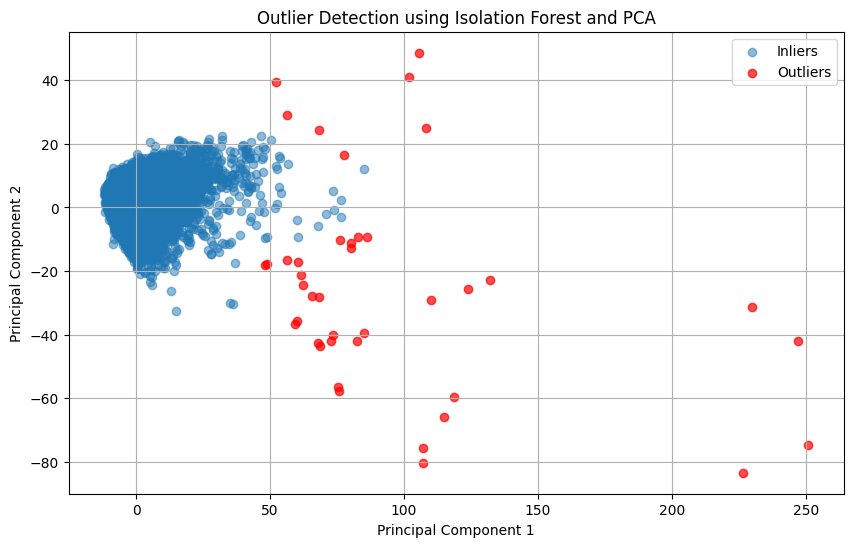

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(train_x_pca[outlier_labels == 1, 0], train_x_pca[outlier_labels == 1, 1], label='Inliers', alpha=0.5)
plt.scatter(train_x_pca[outlier_labels == -1, 0], train_x_pca[outlier_labels == -1, 1], label='Outliers', color='red', alpha=0.7)
plt.title('Outlier Detection using Isolation Forest and PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid()
plt.show()

In [ ]:
#keep only the inliers
train_x = train_x[outlier_labels > 0]
train_y = train_y[outlier_labels > 0]
print("X_train shape:", train_x.shape)
print("y_train shape:", train_y.shape)

X_train shape: (10193, 495)
y_train shape: (10193, 1)
